In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# df.groupby("school_type")[["math_score","science_score","english_score","hindi_score","social_score"]].mean() group inside group 

In [11]:
df = pd.read_csv('student_performance.csv')

In [12]:
df.shape

(35, 20)

In [13]:
df.head()

,student_id,name,gender,age,school_type,parental_education,study_hours_per_day,attendance_percent,math_score,science_score,english_score,hindi_score,social_score,extracurricular,internet_access,family_income,tuition,sleep_hours,stress_level,passed
0,S001,Aarav Sharma,Male,16,Government,Graduate,3,85,72,68,75,80,70,Yes,Yes,Medium,Yes,7,Medium,Yes
1,S002,Priya Patel,Female,15,Private,Post-Graduate,5,95,88,91,92,85,89,Yes,Yes,High,Yes,8,Low,Yes
2,S003,Rohan Verma,Male,17,Government,HSC,1,60,42,38,45,52,40,No,No,Low,No,6,High,No
3,S004,Sneha Iyer,Female,16,Private,Graduate,4,90,80,82,85,78,81,Yes,Yes,High,Yes,7,Low,Yes
4,S005,Vikram Nair,Male,17,Government,SSC,2,70,55,50,58,62,53,No,No,Low,No,5,High,No


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   student_id           35 non-null     str  
 1   name                 35 non-null     str  
 2   gender               35 non-null     str  
 3   age                  35 non-null     int64
 4   school_type          35 non-null     str  
 5   parental_education   35 non-null     str  
 6   study_hours_per_day  35 non-null     int64
 7   attendance_percent   35 non-null     int64
 8   math_score           35 non-null     int64
 9   science_score        35 non-null     int64
 10  english_score        35 non-null     int64
 11  hindi_score          35 non-null     int64
 12  social_score         35 non-null     int64
 13  extracurricular      35 non-null     str  
 14  internet_access      35 non-null     str  
 15  family_income        35 non-null     str  
 16  tuition              35 non-null     st

In [15]:
df.isnull().sum()

student_id             0
name                   0
gender                 0
age                    0
school_type            0
parental_education     0
study_hours_per_day    0
attendance_percent     0
math_score             0
science_score          0
english_score          0
hindi_score            0
social_score           0
extracurricular        0
internet_access        0
family_income          0
tuition                0
sleep_hours            0
stress_level           0
passed                 0
dtype: int64

In [16]:
df.describe() 

,age,study_hours_per_day,attendance_percent,math_score,science_score,english_score,hindi_score,social_score,sleep_hours
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,16.057143,3.285714,79.428571,68.142857,66.428571,70.885714,71.514286,67.314286,6.742857
std,0.802308,1.525690,13.914203,18.851030,20.540184,18.397205,14.260953,19.147679,0.980482
min,15.000000,1.000000,52.000000,35.000000,33.000000,38.000000,44.000000,35.000000,5.000000
25%,15.000000,2.000000,67.500000,49.500000,47.000000,54.000000,59.500000,49.000000,6.000000
50%,16.000000,3.000000,83.000000,71.000000,67.000000,73.000000,76.000000,69.000000,7.000000
75%,17.000000,4.000000,90.500000,83.500000,84.000000,86.500000,81.000000,83.500000,7.000000
max,17.000000,6.000000,97.000000,94.000000,96.000000,95.000000,92.000000,93.000000,8.000000


In [17]:
df.duplicated().sum()

np.int64(0)

# SOLUTIONS

In [18]:
df.sample(3)

,student_id,name,gender,age,school_type,parental_education,study_hours_per_day,attendance_percent,math_score,science_score,english_score,hindi_score,social_score,extracurricular,internet_access,family_income,tuition,sleep_hours,stress_level,passed
29,S030,Uma Krishnamurthy,Female,15,Private,Graduate,4,88,81,83,85,79,82,Yes,Yes,High,Yes,7,Low,Yes
27,S028,Anita Desai,Female,17,Private,Post-Graduate,5,94,90,91,92,89,90,Yes,Yes,High,Yes,8,Low,Yes
16,S017,Rajesh Choudhary,Male,15,Private,Graduate,4,89,81,79,83,78,80,No,Yes,Medium,Yes,7,Medium,Yes


In [24]:
# 1. Create total_score column
df["total_score"] = (
    df["math_score"] +
    df["science_score"] +
    df["english_score"] +
    df["hindi_score"] +
    df["social_score"]
)

# 2. Create percentage column
df["percentage"] = (df["total_score"] / 500) * 100

# 3. Convert passed column to numeric (Yes=1, No=0)
df["passed_num"] = df["passed"].map({"Yes": 1, "No": 0})

# 4. Check average scores by stress_level
stress_group_scores = df.groupby("stress_level")["percentage"].mean()



In [23]:
df.head()

,student_id,name,gender,age,school_type,parental_education,study_hours_per_day,attendance_percent,math_score,science_score,...,extracurricular,internet_access,family_income,tuition,sleep_hours,stress_level,passed,total_score,percentage,passed_num
0,S001,Aarav Sharma,Male,16,Government,Graduate,3,85,72,68,...,Yes,Yes,Medium,Yes,7,Medium,Yes,365,73.0,1
1,S002,Priya Patel,Female,15,Private,Post-Graduate,5,95,88,91,...,Yes,Yes,High,Yes,8,Low,Yes,445,89.0,1
2,S003,Rohan Verma,Male,17,Government,HSC,1,60,42,38,...,No,No,Low,No,6,High,No,217,43.4,0
3,S004,Sneha Iyer,Female,16,Private,Graduate,4,90,80,82,...,Yes,Yes,High,Yes,7,Low,Yes,406,81.2,1
4,S005,Vikram Nair,Male,17,Government,SSC,2,70,55,50,...,No,No,Low,No,5,High,No,278,55.6,0


In [25]:
stress_group_scores

stress_level
High      47.033333
Low       87.092308
Medium    71.340000
Name: percentage, dtype: float64

In [26]:
df.groupby("school_type")[["math_score","science_score","english_score","hindi_score","social_score"]].mean()

,math_score,science_score,english_score,hindi_score,social_score
school_type,,,,,
Government,53.631579,50.052632,56.631579,61.736842,52.263158
Private,85.375000,85.875000,87.812500,83.125000,85.187500


In [31]:
mean_scores = df.groupby("school_type")[["math_score","science_score","english_score","hindi_score","social_score"]].mean()
score_gap = (mean_scores.loc["Private"] - mean_scores.loc["Government"]).abs()

print("\nScore gaps between Private and Government:\n",score_gap)


Score gaps between Private and Government:
 math_score       31.743421
science_score    35.822368
english_score    31.180921
hindi_score      21.388158
social_score     32.924342
dtype: float64


In [32]:
biggest_gap_subject = score_gap.idxmax()
biggest_gap_value = score_gap.max()

print(f"\nBiggest gap is in {biggest_gap_subject} with a difference of {biggest_gap_value:.2f} points.")


Biggest gap is in science_score with a difference of 35.82 points.


In [33]:
df.head()

,student_id,name,gender,age,school_type,parental_education,study_hours_per_day,attendance_percent,math_score,science_score,...,extracurricular,internet_access,family_income,tuition,sleep_hours,stress_level,passed,total_score,percentage,passed_num
0,S001,Aarav Sharma,Male,16,Government,Graduate,3,85,72,68,...,Yes,Yes,Medium,Yes,7,Medium,Yes,365,73.0,1
1,S002,Priya Patel,Female,15,Private,Post-Graduate,5,95,88,91,...,Yes,Yes,High,Yes,8,Low,Yes,445,89.0,1
2,S003,Rohan Verma,Male,17,Government,HSC,1,60,42,38,...,No,No,Low,No,6,High,No,217,43.4,0
3,S004,Sneha Iyer,Female,16,Private,Graduate,4,90,80,82,...,Yes,Yes,High,Yes,7,Low,Yes,406,81.2,1
4,S005,Vikram Nair,Male,17,Government,SSC,2,70,55,50,...,No,No,Low,No,5,High,No,278,55.6,0


In [36]:
# # (df['passed_num']==0)['student_id']

# For students who failed, find the mean study_hours_per_day, mean attendance_percent, and mode of family_income. What do you observe?
# Calculate the mean percentage score by parental_education level. Does higher parental education lead to higher scores?
# Find the variance and standard deviation of math_score and english_score. Which subject has more consistent scores across students?

In [37]:
# Filter failed students
failed = df[df["passed"] == "No"]

print("Mean study hours:", failed["study_hours_per_day"].mean())
print("Mean attendance:", failed["attendance_percent"].mean())
print("Mode family income:", failed["family_income"].mode()[0])


Mean study hours: 1.5833333333333333
Mean attendance: 62.5
Mode family income: Low


In [40]:
# Mean percentage score by parental education
mean_by_edu = df.groupby("parental_education")["percentage"].mean().sort_values(ascending=False)

print(mean_by_edu)

# Find which level is highest
highest = mean_by_edu.idxmax()
print(f"Highest mean percentage is for: {highest}")


parental_education
Post-Graduate    90.450000
Graduate         75.400000
HSC              53.633333
SSC              44.142857
Name: percentage, dtype: float64
Highest mean percentage is for: Post-Graduate


In [41]:
# Variance and standard deviation
print("Math variance:", df["math_score"].var())
print("Math std dev:", df["math_score"].std())

print("English variance:", df["english_score"].var())
print("English std dev:", df["english_score"].std())


Math variance: 355.3613445378151
Math std dev: 18.85103033093457
English variance: 338.4571428571429
English std dev: 18.397204756623843


In [42]:
# Top 5
top5 = df.nlargest(5, "total_score")[["name","total_score","study_hours_per_day","attendance_percent"]]

# Bottom 5
bottom5 = df.nsmallest(5, "total_score")[["name","total_score","study_hours_per_day","attendance_percent"]]

print("Top 5 students:\n", top5)
print("\nBottom 5 students:\n", bottom5)


Top 5 students:
             name  total_score  study_hours_per_day  attendance_percent
5   Anjali Gupta          470                    6                  97
32   Pavan Kumar          467                    6                  97
18   Nikhil Bose          462                    6                  96
27   Anita Desai          452                    5                  94
1    Priya Patel          445                    5                  95

Bottom 5 students:
               name  total_score  study_hours_per_day  attendance_percent
22   Suresh Pillai          185                    1                  52
30    Ravi Shankar          193                    1                  54
12   Sanjay Pillai          195                    1                  55
17  Sunita Agarwal          213                    1                  58
2      Rohan Verma          217                    1                  60


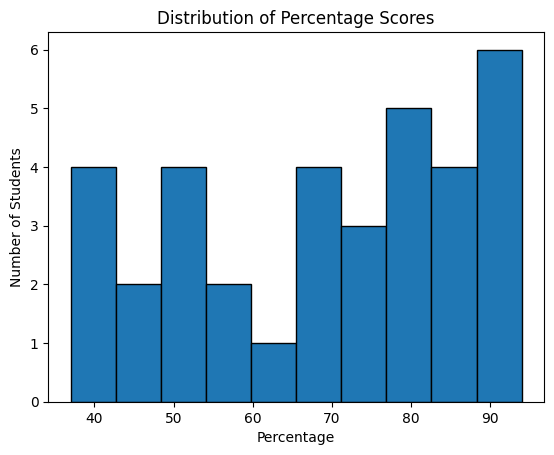

In [43]:
import matplotlib.pyplot as plt

plt.hist(df["percentage"], bins=10, edgecolor="black")
plt.xlabel("Percentage")
plt.ylabel("Number of Students")
plt.title("Distribution of Percentage Scores")
plt.show()


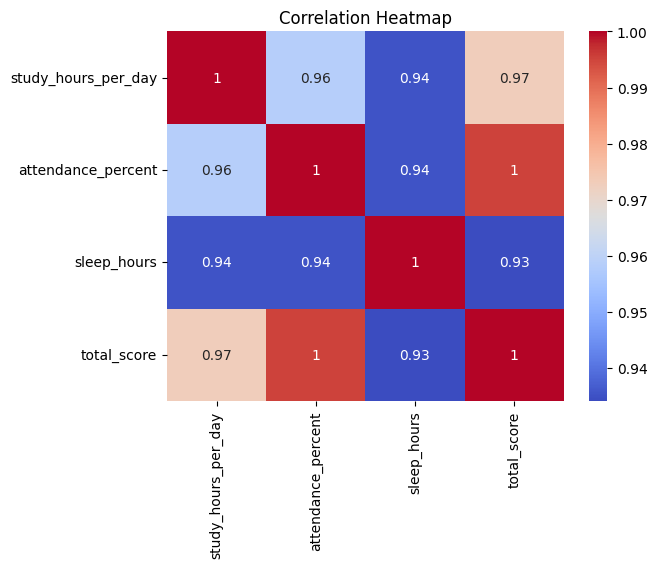

In [44]:
import seaborn as sns

cols = ["study_hours_per_day", "attendance_percent", "sleep_hours", "total_score"]
corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
